In [2]:
# Here importing all the required libraries for the project:
import torch 
import torch.nn as nn
import cv2 as cv
import numpy as np
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import torch.nn as nn
import torch.optim as optim

In [3]:
import os 
import pandas as pd 


train_dir = "C:\\Users\\ravi.dalal\\Desktop\\Python\\Projects\\Defect_Classification\\Datasets\\NEU-DET\\train\\images"

image_paths = []
labels = []

for class_name in os.listdir(train_dir):
    class_folder = os.path.join(train_dir, class_name)

    if os.path.isdir(class_folder):

        for image_name in os.listdir(class_folder):

            image_paths.append(os.path.join(class_folder, image_name))
            labels.append(class_name)


df = pd.DataFrame({
    "image_path" : image_paths,
    "label": labels
})

In [5]:
# Verify the DataFrame
print(f"First few rows of the DataFrame:\n{df.head()}")
print(f"Value counts for each class:\n{df['label'].value_counts()}")
print(f"Number of unique classes: {df['label'].nunique()}") 
print(f"Unique class labels: {df['label'].unique()}") 
print(f"Class distribution:\n{df['label'].value_counts(normalize=True)}")  # To see the distribution of classes

First few rows of the DataFrame:
                                          image_path    label
0  C:\Users\ravi.dalal\Desktop\Python\Projects\De...  crazing
1  C:\Users\ravi.dalal\Desktop\Python\Projects\De...  crazing
2  C:\Users\ravi.dalal\Desktop\Python\Projects\De...  crazing
3  C:\Users\ravi.dalal\Desktop\Python\Projects\De...  crazing
4  C:\Users\ravi.dalal\Desktop\Python\Projects\De...  crazing
Value counts for each class:
label
crazing            240
inclusion          240
patches            240
pitted_surface     240
rolled-in_scale    240
scratches          240
Name: count, dtype: int64
Number of unique classes: 6
Unique class labels: <ArrowStringArray>
[        'crazing',       'inclusion',         'patches',  'pitted_surface',
 'rolled-in_scale',       'scratches']
Length: 6, dtype: str
Class distribution:
label
crazing            0.166667
inclusion          0.166667
patches            0.166667
pitted_surface     0.166667
rolled-in_scale    0.166667
scratches          0.166

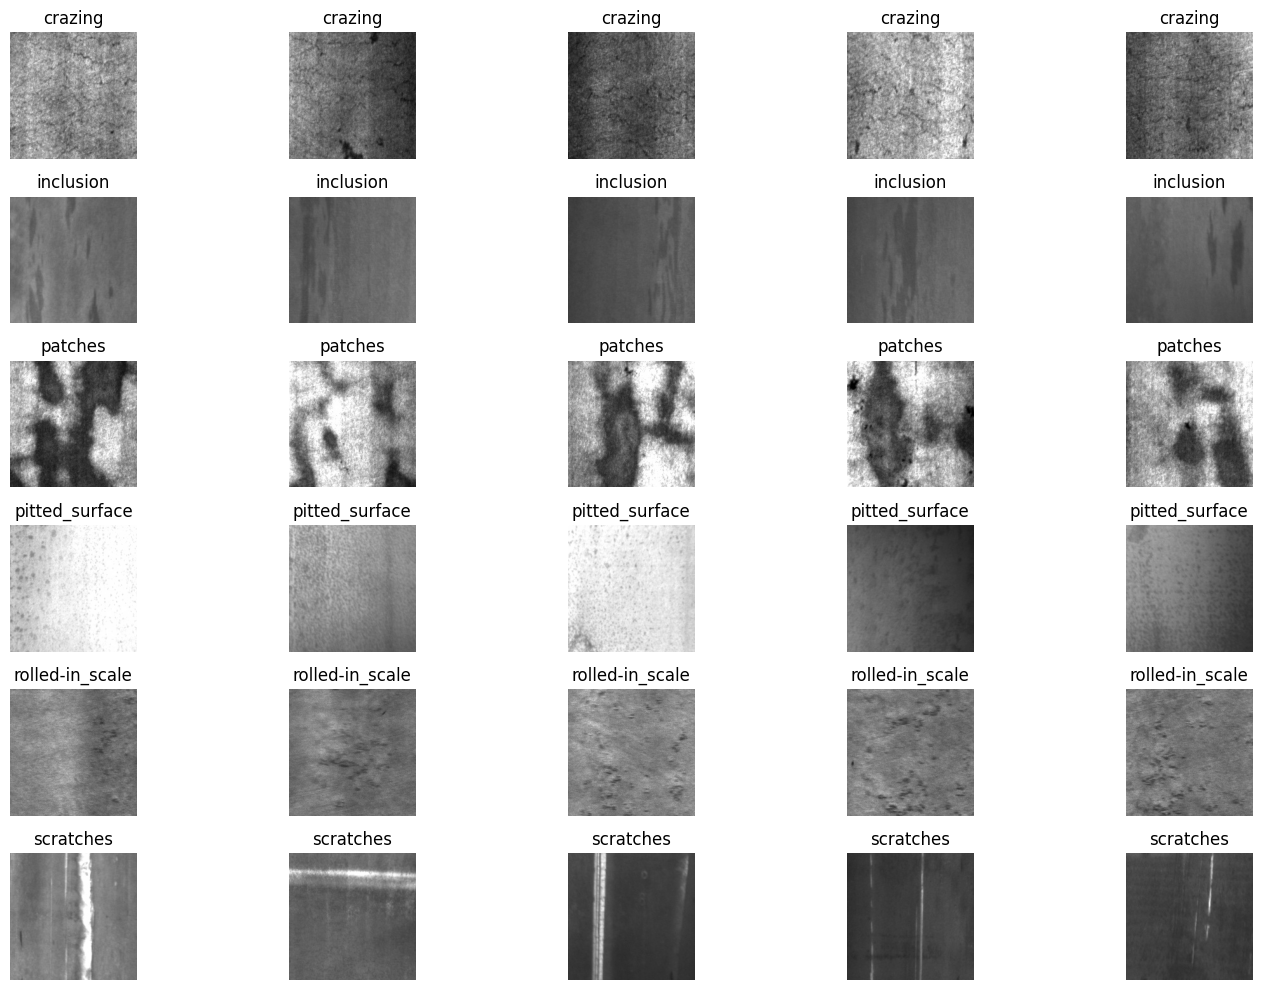

In [6]:
# Display random images from each class
from PIL import Image
plt.figure(figsize=(15, 10))

plot_index = 1

for class_name in df["label"].unique():
    sample_paths = df[df["label"] == class_name]["image_path"].sample(5, random_state=42)

    for path in sample_paths:
        img = Image.open(path)

        plt.subplot(df["label"].nunique(), 5, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()





In [7]:
# Split dataframe:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [8]:
# Check class distribution after split:
print("Train class distribution:")
print(train_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_df["label"].value_counts())

Train class distribution:
label
pitted_surface     192
inclusion          192
crazing            192
patches            192
scratches          192
rolled-in_scale    192
Name: count, dtype: int64

Validation class distribution:
label
patches            48
crazing            48
inclusion          48
pitted_surface     48
rolled-in_scale    48
scratches          48
Name: count, dtype: int64


In [9]:
# Create class-to-index and index-to-class mappings:
class_names = sorted(train_df["label"].unique())

class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

print(class_to_idx)

{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [10]:
# Build custom Dataset class
class NEUDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.dataframe = dataframe
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "image_path"]
        label_name = self.dataframe.loc[index, "label"]

        image = Image.open(image_path).convert("RGB")
        label = self.class_to_idx[label_name]

        if self.transform:
            image = self.transform(image)
        
        return image, label
    

In [11]:
# Define transforms:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
# Create train and validation datasets:

train_dataset = NEUDataset(
    dataframe=train_df,
    class_to_idx=class_to_idx,
    transform=train_transform
)

val_dataset = NEUDataset(
    dataframe=val_df,
    class_to_idx=class_to_idx,
    transform=val_transform
)

In [13]:
# Test one sample:
image, label = train_dataset[2]

print(image.shape)
print(label)
print(idx_to_class[label])

torch.Size([3, 224, 224])
0
crazing


In [14]:
# create the dataloaders
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [15]:
# test one batch:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [17]:
# Build custom CNN model:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [18]:
# Create model object:
num_classes = len(class_names)

model = BaselineCNN(num_classes=num_classes).to(device)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, aff

In [19]:
# Define loss function and optimizer:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [20]:
# Training loop:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 8.8120 Train Acc: 41.15% Val Loss: 7.5388 Val Acc: 40.28%
Epoch [2/10] Train Loss: 1.8053 Train Acc: 61.55% Val Loss: 0.7477 Val Acc: 74.31%
Epoch [3/10] Train Loss: 1.0271 Train Acc: 67.36% Val Loss: 0.4917 Val Acc: 82.29%
Epoch [4/10] Train Loss: 0.7512 Train Acc: 74.05% Val Loss: 0.3836 Val Acc: 87.50%
Epoch [5/10] Train Loss: 0.6367 Train Acc: 77.60% Val Loss: 0.3483 Val Acc: 88.19%
Epoch [6/10] Train Loss: 0.6332 Train Acc: 80.12% Val Loss: 0.4197 Val Acc: 86.81%
Epoch [7/10] Train Loss: 0.5581 Train Acc: 82.29% Val Loss: 0.3495 Val Acc: 88.19%
Epoch [8/10] Train Loss: 0.5696 Train Acc: 81.60% Val Loss: 0.3056 Val Acc: 88.89%
Epoch [9/10] Train Loss: 0.5511 Train Acc: 80.90% Val Loss: 0.3089 Val Acc: 89.58%
Epoch [10/10] Train Loss: 0.5300 Train Acc: 82.64% Val Loss: 0.3958 Val Acc: 87.15%


In [22]:
# Save the BaselineCNN model:
torch.save(
    model.state_dict(), "baseline_cnn_neu_finetuned.pth")

ResNet50 Transfer Learning

In [23]:
# Import Libraries:
import torch.optim as optim
from torchvision import models


In [24]:
# Load pretrained ResNet50:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)


In [25]:
# Freeze feature extractor layers:
for param in model.parameters():
    param.requires_grad = False

In [26]:
# Replace final classification layer:
num_classes = len(class_name)
# Original ResNet50 predicts 1000 ImageNet classes. But in our datasets there are only 6 classes.
model.fc = nn.Linear(model.fc.in_features, num_classes)


In [27]:
# Move model to device:
model = model.to(device)


In [28]:
# Define loss and optimizer:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr= 0.001)


In [29]:
# Training loop:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total
    train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 1.2461 Train Acc: 74.05% Val Loss: 1.2331 Val Acc: 76.39%
Epoch [2/10] Train Loss: 0.5086 Train Acc: 95.23% Val Loss: 0.4887 Val Acc: 97.22%
Epoch [3/10] Train Loss: 0.3342 Train Acc: 95.40% Val Loss: 0.2630 Val Acc: 97.57%
Epoch [4/10] Train Loss: 0.2485 Train Acc: 96.70% Val Loss: 0.1997 Val Acc: 96.53%
Epoch [5/10] Train Loss: 0.2077 Train Acc: 97.31% Val Loss: 0.1554 Val Acc: 97.92%
Epoch [6/10] Train Loss: 0.1788 Train Acc: 97.48% Val Loss: 0.1320 Val Acc: 97.92%
Epoch [7/10] Train Loss: 0.1449 Train Acc: 97.57% Val Loss: 0.1148 Val Acc: 98.61%
Epoch [8/10] Train Loss: 0.1379 Train Acc: 97.66% Val Loss: 0.1049 Val Acc: 98.26%
Epoch [9/10] Train Loss: 0.1326 Train Acc: 97.14% Val Loss: 0.0844 Val Acc: 99.31%
Epoch [10/10] Train Loss: 0.1155 Train Acc: 98.09% Val Loss: 0.0899 Val Acc: 98.26%


Fine-tuning stage

In [30]:
# Unfreeze last ResNet block:
for param in model.layer4.parameters():
    param.requires_grad = True

In [31]:
# Use a smaller learning rate:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001)

In [30]:
# Training loop:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}
num_epochs = 8

for epoch in range(num_epochs):

    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total
    train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

history["train_loss"].append(train_loss)
history["val_loss"].append(val_loss)
history["train_acc"].append(train_accuracy)
history["val_acc"].append(val_accuracy)

Epoch [1/8] Train Loss: 0.0597 Train Acc: 98.87% Val Loss: 0.0209 Val Acc: 99.31%
Epoch [2/8] Train Loss: 0.0192 Train Acc: 99.39% Val Loss: 0.0064 Val Acc: 100.00%
Epoch [3/8] Train Loss: 0.0214 Train Acc: 99.22% Val Loss: 0.0043 Val Acc: 100.00%
Epoch [4/8] Train Loss: 0.0098 Train Acc: 99.74% Val Loss: 0.0040 Val Acc: 100.00%
Epoch [5/8] Train Loss: 0.0084 Train Acc: 99.83% Val Loss: 0.0029 Val Acc: 100.00%
Epoch [6/8] Train Loss: 0.0081 Train Acc: 99.74% Val Loss: 0.0022 Val Acc: 100.00%
Epoch [7/8] Train Loss: 0.0061 Train Acc: 99.83% Val Loss: 0.0013 Val Acc: 100.00%
Epoch [8/8] Train Loss: 0.0075 Train Acc: 99.74% Val Loss: 0.0007 Val Acc: 100.00%


In [32]:
# Save the model for direct use;
torch.save(model.state_dict(), "resnet50_neu_finetuned.pth")

In [32]:
# Import required matrics:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [35]:
# Load the fine tunning model:
model.load_state_dict(torch.load("C:\\Users\\ravi.dalal\\Desktop\\Python\\Projects\\Defect_Classification\\models\\resnet50_neu_finetuned.pth", map_location=device))
model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [37]:
# Load the Test data
test_dir = r"C:\\Users\\ravi.dalal\\Desktop\\Python\\Projects\\Defect_Classification\\Datasets\\NEU-DET\\test\\images"

# Convert it into Pandas Dataframe
test_image_paths = []
test_labels = []

for test_class_name in os.listdir(test_dir):
    test_class_folder = os.path.join(test_dir, test_class_name)

    if os.path.isdir(test_class_folder):
        for test_image_name in os.listdir(test_class_folder):
            test_image_path = os.path.join(test_class_folder, test_image_name)

            test_image_paths.append(test_image_path)
            test_labels.append(test_class_name)

test_df = pd.DataFrame({
    "image_path": test_image_paths,
    "label": test_labels
})

# set the test_transform
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#Perpare the Test dataset
test_dataset = NEUDataset(
    dataframe=test_df,
    class_to_idx=class_to_idx,
    transform=test_transform
)

# Perpare the Test Loader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [38]:
# Collect predictions from test data:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [40]:
# Create a DataFrame to store predictions and labels:
df2 = pd.DataFrame({
    "Prediction value" : all_preds,
    "labels": all_labels
})
df2

,Predection value,labels
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
355,5,5
356,5,5
357,5,5
358,5,5


In [42]:
# Classification report:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      0.98      0.99        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.98      1.00      0.99        60

       accuracy                           1.00       360
      macro avg       1.00      1.00      1.00       360
   weighted avg       1.00      1.00      1.00       360



<Figure size 1000x800 with 0 Axes>

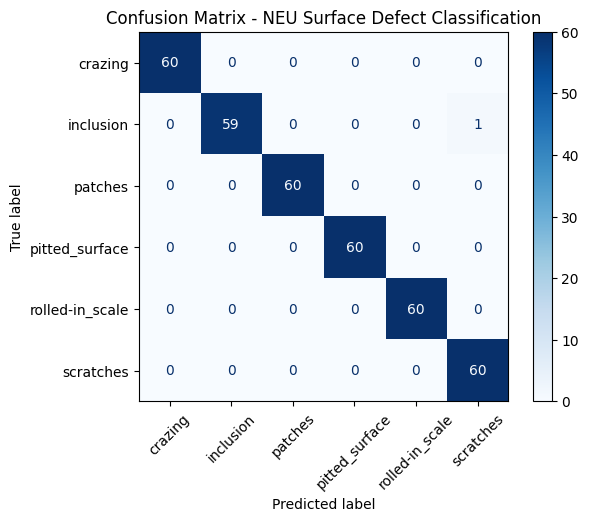

In [43]:
# Confusion matrix:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - NEU Surface Defect Classification")
plt.show()

In [44]:
# Test accuracy:
test_accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 99.72%


In [45]:
# Save results:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv("classification_report.csv")

print(report_df)

                 precision    recall  f1-score     support
crazing           1.000000  1.000000  1.000000   60.000000
inclusion         1.000000  0.983333  0.991597   60.000000
patches           1.000000  1.000000  1.000000   60.000000
pitted_surface    1.000000  1.000000  1.000000   60.000000
rolled-in_scale   1.000000  1.000000  1.000000   60.000000
scratches         0.983607  1.000000  0.991736   60.000000
accuracy          0.997222  0.997222  0.997222    0.997222
macro avg         0.997268  0.997222  0.997222  360.000000
weighted avg      0.997268  0.997222  0.997222  360.000000


Training Curves:

In [ ]:
# Plot loss curve:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot accuracy curve:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

EfficientNet-B0 Transfer Learning

In [47]:
# Load pretrained EfficientNet-B0:

efficientnet_model = models.efficientnet_b0(weights= models.EfficientNet_B0_Weights.DEFAULT)


In [48]:
# Replace final classifie:
num_classes = len(class_names)

efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_model.classifier[1].in_features,
    num_classes
)

# Move Model to the device
efficientnet_model = efficientnet_model.to(device)

In [49]:
# Define loss and optimizer:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    efficientnet_model.classifier.parameters(),
    lr=0.001
)

In [ ]:
# Training loop:
num_epochs = 10

history_effnet = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(num_epochs):

    efficientnet_model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    efficientnet_model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = efficientnet_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    history_effnet["train_loss"].append(train_loss)
    history_effnet["val_loss"].append(val_loss)
    history_effnet["train_acc"].append(train_accuracy)
    history_effnet["val_acc"].append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

In [ ]:
# Save the model:
torch.save(
    efficientnet_model.state_dict(),
    "efficientnet_b0_neu_feature_extraction.pth"
)

Fine-tune EfficientNet-B0

In [51]:
# Unfreeze last feature block:
for param in efficientnet_model.features[-1].parameters():
    param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet_model.parameters()),
    lr=0.0001
)

In [52]:
# Training loop:
num_epochs = 5

history_effnet = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(num_epochs):

    efficientnet_model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    efficientnet_model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = efficientnet_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    history_effnet["train_loss"].append(train_loss)
    history_effnet["val_loss"].append(val_loss)
    history_effnet["train_acc"].append(train_accuracy)
    history_effnet["val_acc"].append(val_accuracy) 
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/5] Train Loss: 0.2331 Train Acc: 97.48% Val Loss: 0.0574 Val Acc: 98.96%
Epoch [2/5] Train Loss: 0.0527 Train Acc: 99.05% Val Loss: 0.0240 Val Acc: 99.65%
Epoch [3/5] Train Loss: 0.0276 Train Acc: 99.57% Val Loss: 0.0201 Val Acc: 99.65%
Epoch [4/5] Train Loss: 0.0253 Train Acc: 99.48% Val Loss: 0.0102 Val Acc: 99.65%
Epoch [5/5] Train Loss: 0.0218 Train Acc: 99.57% Val Loss: 0.0066 Val Acc: 99.65%


In [53]:
# Save the fine-tuned EfficientNet-B0 model:
torch.save(
    efficientnet_model.state_dict(),
    "efficientnet_b0_neu_finetuned.pth"
)

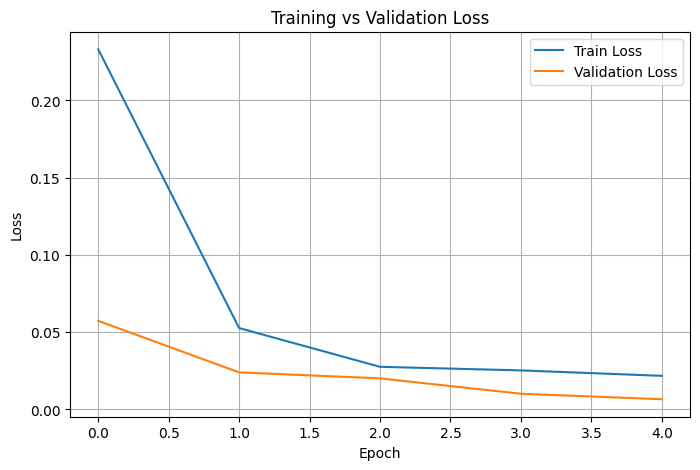

In [55]:
# Plot loss curve:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_effnet["train_loss"], label="Train Loss")
plt.plot(history_effnet["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

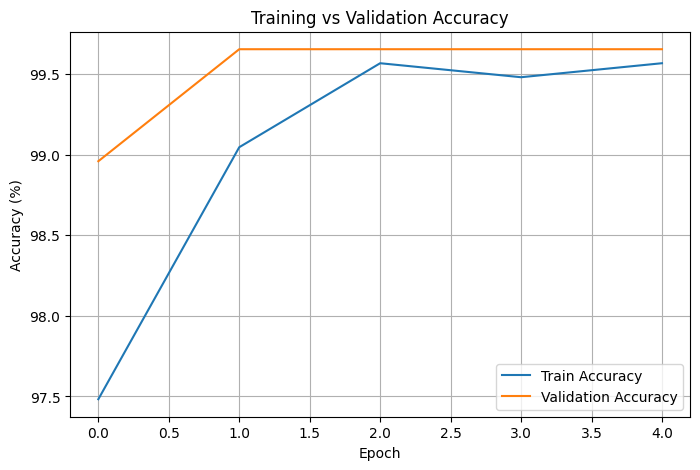

In [56]:
# Plot accuracy curve:
plt.figure(figsize=(8, 5))
plt.plot(history_effnet["train_acc"], label="Train Accuracy")
plt.plot(history_effnet["val_acc"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()